# UNSW-NB15 Network Intrusion Detection: Data Preparation

This notebook documents a comprehensive data preparation pipeline for the UNSW-NB15 network intrusion detection dataset. The pipeline transforms raw network traffic data into a machine learning–ready feature set through systematic data cleaning, preprocessing, and feature engineering. The final dataset enables binary classification of benign vs. malicious network flows.

## 1. Library Importation

In [1]:
# Data Loading & Manipulation
from kagglehub import KaggleDatasetAdapter
import kagglehub
import pandas as pd
import numpy as np

# Data Splitting & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Feature Engineering & Selection
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.decomposition import PCA

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Network utilities
import ipaddress

# Modeling
from xgboost import XGBClassifier

## 2. Data Loading

### Why This Dataset?
UNSW-NB15 is a benchmark dataset for evaluating modern intrusion detection systems. Unlike earlier datasets (NSL-KDD), it contains contemporary attack patterns (e.g., backdoor, DoS, reconnaissance, worms) and benign traffic from a heterogeneous network environment, making it suitable for real-world model development.

In [2]:
# Load feature names from metadata
features = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "mrwellsdavid/unsw-nb15", "NUSW-NB15_features.csv", pandas_kwargs={"encoding":"latin1"})

# Load all four data partitions and apply feature names
file_paths = ["UNSW-NB15_1.csv", "UNSW-NB15_2.csv", "UNSW-NB15_3.csv", "UNSW-NB15_4.csv"]
dfs = []

for file in file_paths:
  data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mrwellsdavid/unsw-nb15",
  file)
  data.columns = features["Name"]
  dfs.append(data)

# Concatenate all partitions into a single dataset
df = pd.concat(dfs, ignore_index=True)
print("\n",df.shape[0],"samples of data has been imported, with",df.shape[1],"features.")

100%|██████████| 3.95k/3.95k [00:00<00:00, 6.80MB/s]


100%|██████████| 41.7M/41.7M [00:00<00:00, 75.2MB/s]

Extracting zip of UNSW-NB15_1.csv...



/usr/local/lib/python3.12/dist-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


100%|██████████| 42.2M/42.2M [00:00<00:00, 105MB/s]

Extracting zip of UNSW-NB15_2.csv...



/usr/local/lib/python3.12/dist-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (3,39,47) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


Using Colab cache for faster access to the 'unsw-nb15' dataset.
Using Colab cache for faster access to the 'unsw-nb15' dataset.

 2540043 samples of data has been imported, with 49 features.


## 3. Exploring Data Characteristics

### Key Questions
- What are the data types and basic statistics ?
- How many missing values exist ?
- Is there class imbalance in the target variable ?
- What is the relationship between the target "Label" and the attack category ?

In [3]:
# Display first record to examine feature names and sample values
df.head(1)

Name,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0


In [4]:
# Display dataset structure, types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2540043 entries, 0 to 2540042
Data columns (total 49 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             object 
 1   sport             object 
 2   dstip             object 
 3   dsport            object 
 4   proto             object 
 5   state             object 
 6   dur               float64
 7   sbytes            int64  
 8   dbytes            int64  
 9   sttl              int64  
 10  dttl              int64  
 11  sloss             int64  
 12  dloss             int64  
 13  service           object 
 14  Sload             float64
 15  Dload             float64
 16  Spkts             int64  
 17  Dpkts             int64  
 18  swin              int64  
 19  dwin              int64  
 20  stcpb             int64  
 21  dtcpb             int64  
 22  smeansz           int64  
 23  dmeansz           int64  
 24  trans_depth       int64  
 25  res_bdy_len       int64  
 26  Sjit          

In [5]:
# Check for missing values by column
df.isna().sum()

,0
Name,
srcip,0
sport,0
dstip,0
dsport,0
proto,0
state,0
dur,0
sbytes,0
dbytes,0


In [6]:
# Display statistical summary
df.describe()

Name,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,Sload,Dload,Spkts,...,ct_flw_http_mthd,is_ftp_login,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,Label
count,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,...,1.191900e+06,1.110166e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06,2.540043e+06
mean,6.587925e-01,4.339589e+03,3.642760e+04,6.278202e+01,3.076681e+01,5.163917e+00,1.632944e+01,3.695650e+07,2.450860e+06,3.328882e+01,...,2.345860e-01,3.969947e-02,9.206993e+00,8.988962e+00,6.439107e+00,6.900989e+00,4.642145e+00,3.592733e+00,6.845894e+00,1.264872e-01
std,1.392494e+01,5.640604e+04,1.610962e+05,7.462281e+01,4.285092e+01,2.251709e+01,5.659479e+01,1.186044e+08,4.224865e+06,7.628393e+01,...,7.940930e-01,1.996591e-01,1.083676e+01,1.082250e+01,8.162039e+00,8.205068e+00,8.477584e+00,6.174449e+00,1.125829e+01,3.323977e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,1.037000e-03,2.000000e+02,1.780000e+02,3.100000e+01,2.900000e+01,0.000000e+00,0.000000e+00,1.353955e+05,1.191580e+04,2.000000e+00,...,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,1.586100e-02,1.470000e+03,1.820000e+03,3.100000e+01,2.900000e+01,3.000000e+00,4.000000e+00,5.893038e+05,5.893179e+05,1.200000e+01,...,0.000000e+00,0.000000e+00,5.000000e+00,5.000000e+00,3.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00
75%,2.145650e-01,3.182000e+03,1.489400e+04,3.100000e+01,2.900000e+01,7.000000e+00,1.400000e+01,2.039923e+06,2.925945e+06,4.400000e+01,...,0.000000e+00,0.000000e+00,1.000000e+01,1.000000e+01,6.000000e+00,7.000000e+00,2.000000e+00,1.000000e+00,5.000000e+00,0.000000e+00
max,8.786638e+03,1.435577e+07,1.465753e+07,2.550000e+02,2.540000e+02,5.319000e+03,5.507000e+03,5.988000e+09,1.287619e+08,1.064600e+04,...,3.600000e+01,4.000000e+00,6.700000e+01,6.700000e+01,6.700000e+01,6.700000e+01,6.700000e+01,6.000000e+01,6.700000e+01,1.000000e+00


In [7]:
df["Label"].unique()

array([0, 1])

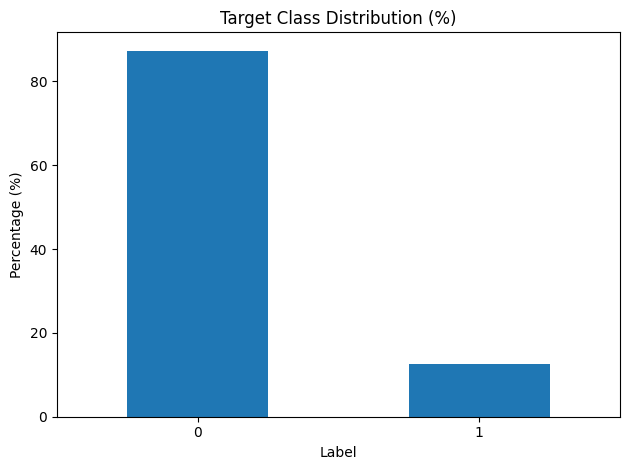

In [8]:
# Visualize class distribution
(df["Label"].value_counts(normalize=True) * 100).plot(kind="bar")
plt.ylabel("Percentage (%)")
plt.title("Target Class Distribution (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Examine attack categories within each label class
print("Label = 0 (Normal) -> attack category =",df[df["Label"] == 0]["attack_cat"].unique())
print("Label = 1 (Attack) -> attack categories =",df[df["Label"] == 1]["attack_cat"].unique())

Label = 0 (Normal) -> attack category = [nan]
Label = 1 (Attack) -> attack categories = ['Exploits' 'Reconnaissance' 'DoS' 'Generic' 'Shellcode' ' Fuzzers'
 'Worms' 'Backdoors' 'Analysis' ' Reconnaissance ' 'Backdoor' ' Fuzzers '
 ' Shellcode ']


## 4. Data Cleaning

In [10]:
# Drop 'attack_cat', removing this feature prevents data leakage
df.drop(columns=["attack_cat"], inplace=True)

In [11]:
# Remove duplicate records
df = df.drop_duplicates(ignore_index=True)

print(f"Shape after duplicate removal: {df.shape}")

Shape after duplicate removal: (2048617, 48)


In [12]:
# Convert timestamps (Stime, Ltime) to datetime objects for feature extraction
df.Ltime = pd.to_datetime(df["Ltime"], unit="s", errors="coerce")
df.Stime = pd.to_datetime(df["Stime"], unit="s", errors="coerce")

In [13]:
# Extract temporal features and drop Stime/Ltime as their granularity is insufficient for prediction
print("Hours present:", df.Stime.dt.hour.unique())
print("Days present:", df.Stime.dt.day.unique())
print("Years present:", df.Stime.dt.year.unique())
print("Months present:", df.Stime.dt.month.unique())

df.drop(columns=['Stime','Ltime'], inplace=True)

Hours present: [11 12 13 14 15 16 17 18 19 20 21 22 23  0  1  2  3  4  5  6  7  8  9 10]
Days present: [22 23 18]
Years present: [2015]
Months present: [1 2]


In [14]:
# Extract IP privacy status from source and destination IPs
def is_private(ip):
    try:
        return int(ipaddress.ip_address(ip).is_private)
    except:
        return 0

df["src_is_private"] = df["srcip"].apply(is_private)
df["dst_is_private"] = df["dstip"].apply(is_private)
df.drop(["srcip", "dstip"], axis=1, inplace=True)

In [15]:
# Standardize string categorical columns to lowercase and remove whitespace
df['proto'] = df['proto'].apply(lambda x: x.lower().strip())
df['state'] = df['state'].apply(lambda x: x.lower().strip())
df['service'] = df['service'].apply(lambda x: x.lower().strip())

In [16]:
# Convert columns mistakenly stored as objects to numeric
df.ct_ftp_cmd = pd.to_numeric(df.ct_ftp_cmd, errors="coerce")
df.sport = pd.to_numeric(df.sport, errors="coerce")
df.dsport = pd.to_numeric(df.dsport, errors="coerce")

In [17]:
# Drop rows with missing values
df.dropna(inplace=True)

print(f"Shape after missing value removal: {df.shape}")

Shape after missing value removal: (1022064, 46)


In [18]:
# Ensure integer columns are explicitly int type
df.sport = df.sport.astype(int)
df.dsport = df.dsport.astype(int)
df.is_ftp_login = df.is_ftp_login.astype(int)

In [19]:
# Fix column name typo from original metadata
df.rename(columns={'ct_src_ ltm': 'ct_src_ltm'}, inplace=True)

## 5. Train–Test Split

In [20]:
X = df.drop(columns=["Label"])
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print(f"Train class distribution:\n{y_train.value_counts().to_string()}")
print(f"\nTest class distribution:\n{y_test.value_counts().to_string()}")

X_train shape: (817651, 45)
X_test shape: (204413, 45)
Train class distribution:
Label
0    807081
1     10570

Test class distribution:
Label
0    201770
1      2643


## 6. Data Preprocessing

In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 817651 entries, 346731 to 720868
Data columns (total 45 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sport             817651 non-null  int64  
 1   dsport            817651 non-null  int64  
 2   proto             817651 non-null  object 
 3   state             817651 non-null  object 
 4   dur               817651 non-null  float64
 5   sbytes            817651 non-null  int64  
 6   dbytes            817651 non-null  int64  
 7   sttl              817651 non-null  int64  
 8   dttl              817651 non-null  int64  
 9   sloss             817651 non-null  int64  
 10  dloss             817651 non-null  int64  
 11  service           817651 non-null  object 
 12  Sload             817651 non-null  float64
 13  Dload             817651 non-null  float64
 14  Spkts             817651 non-null  int64  
 15  Dpkts             817651 non-null  int64  
 16  swin              81

In [22]:
# Examine 'state' categorical column
print(f"Unique states: {X_train.state.unique()}")
print("\nState value counts:")
print(X_train.state.value_counts())

Unique states: ['fin' 'con' 'int' 'req' 'acc' 'urh' 'rst' 'clo' 'mas' 'eco' 'no' 'ecr']

State value counts:
state
fin    580411
con    227473
int      7898
req      1611
clo       124
rst        60
urh        40
acc        22
eco         9
mas         1
no          1
ecr         1
Name: count, dtype: int64


In [23]:
# Examine 'service' categorical column
print(f"Unique services: {X_train.service.unique()}")
print("\nService value counts:")
print(X_train.service.value_counts())

Unique services: ['ssh' '-' 'dns' 'http' 'ftp' 'ftp-data' 'smtp' 'pop3' 'radius' 'dhcp'
 'ssl' 'snmp' 'irc']

Service value counts:
service
-           483553
dns         142725
http         74909
ftp-data     49361
smtp         30774
ssh          18678
ftp          17468
pop3           145
ssl             16
snmp            11
dhcp             5
radius           4
irc              2
Name: count, dtype: int64


In [24]:
# Examine 'proto' categorical column
print(f"Unique protocols: {X_train.proto.unique()}")
print("\nProtocol value counts:")
print(X_train.proto.value_counts())

Unique protocols: ['tcp' 'udp' 'arp' 'ospf' 'icmp' 'fire' 'unas' 'ptp' 'sctp' 'igmp'
 'ipv6-route' 'argus' 'uti' 'vrrp' 'br-sat-mon' 'pri-enc' 'qnx' 'hmp'
 'pim' 'any' 'swipe' 'ggp' 'pgm' 'udt' 'ddp' 'xns-idp' 'tcf' 'pipe'
 'mobile' 'irtp' 'sep' 'ipv6-opts' 'mtp' 'sat-mon' 'crtp' 'dcn' 'ipcomp'
 'iatp' 'mux' 'xtp' 'ipv6-frag' 'i-nlsp' 'ipx-n-ip' 'prm' 'mhrp' 'ax.25'
 'st2' 'idrp' 'aris' 'trunk-1' 'ipip' 'bbn-rcc' 'sm' 'pup' 'igp'
 'sccopmce' 'zero' 'egp' 'iplt' 'rvd' 'tlsp' 'vmtp' 'ipv6-no' 'ddx' 'isis'
 'iso-tp4' 'larp' 'emcon' 'etherip' 'dgp' 'leaf-2' 'wsn' 'nsfnet-igp'
 'rsvp' 'pvp' 'ippc' 'sun-nd' '3pc' 'tp++' 'il' 'ipcv' 'rdp' 'wb-mon'
 'leaf-1' 'cftp' 'cbt' 'ipv6' 'netblt' 'crudp' 'srp' 'sprite-rpc' 'sdrp'
 'a/n' 'snp' 'idpr' 'chaos' 'xnet' 'ib' 'fc' 'narp' 'encap' 'nvp'
 'mfe-nsp' 'stp' 'l2tp' 'compaq-peer' 'ip' 'vines' 'iso-ip' 'secure-vmtp'
 'smp' 'gmtp']

Protocol value counts:
proto
tcp            586834
udp            226641
arp              2649
ospf             1250
unas 

In [25]:
# Categorical encoding
common_proto = X_train["proto"].value_counts().nlargest(6).index
common_state = X_train["state"].value_counts().nlargest(5).index
common_service = X_train["service"].value_counts().nlargest(7).index

# Replace rare categories with 'other'
X_train["proto"] = X_train["proto"].where(X_train["proto"].isin(common_proto), "other")
X_test["proto"] = X_test["proto"].where(X_test["proto"].isin(common_proto), "other")
X_train["state"] = X_train["state"].where(X_train["state"].isin(common_state), "other")
X_test["state"] = X_test["state"].where(X_test["state"].isin(common_state), "other")
X_train["service"] = X_train["service"].where(X_train["service"].isin(common_service), "other")
X_test["service"] = X_test["service"].where(X_test["service"].isin(common_service), "other")

X_test = pd.get_dummies(X_test, columns=["proto","state","service"], drop_first=True, dtype=int)
X_train = pd.get_dummies(X_train, columns=["proto","state","service"], drop_first=True, dtype=int)

# Ensure test set has identical columns as train set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [26]:
# Verify all features are now numeric (int64) after one-hot encoding
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 817651 entries, 346731 to 720868
Data columns (total 60 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sport             817651 non-null  int64  
 1   dsport            817651 non-null  int64  
 2   dur               817651 non-null  float64
 3   sbytes            817651 non-null  int64  
 4   dbytes            817651 non-null  int64  
 5   sttl              817651 non-null  int64  
 6   dttl              817651 non-null  int64  
 7   sloss             817651 non-null  int64  
 8   dloss             817651 non-null  int64  
 9   Sload             817651 non-null  float64
 10  Dload             817651 non-null  float64
 11  Spkts             817651 non-null  int64  
 12  Dpkts             817651 non-null  int64  
 13  swin              817651 non-null  int64  
 14  dwin              817651 non-null  int64  
 15  stcpb             817651 non-null  int64  
 16  dtcpb             81

In [27]:
# Identify binary (0/1) columns created from one-hot encoding
bool_cols = []
for i in X_train.select_dtypes(include=['int64']):
  l = X_train[i].unique()
  if len(l) == 2 and 1 in l and 0 in l:
    bool_cols.append(i)

bool_cols

['is_sm_ips_ports',
 'is_ftp_login',
 'src_is_private',
 'dst_is_private',
 'proto_icmp',
 'proto_ospf',
 'proto_other',
 'proto_tcp',
 'proto_udp',
 'proto_unas',
 'state_con',
 'state_fin',
 'state_int',
 'state_other',
 'state_req',
 'service_dns',
 'service_ftp',
 'service_ftp-data',
 'service_http',
 'service_other',
 'service_smtp',
 'service_ssh']

In [28]:
# Standardize numeric features
num_cols = X_train.columns.difference(bool_cols)

X_train_scaled = X_train.copy()

scaler = StandardScaler()
X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])

print(f"Scaled {len(num_cols)} numeric features (excluded {len(bool_cols)} binary features)")
print("\nFirst 5 records (post-scaling):")
print(X_train_scaled.head())

Scaled 38 numeric features (excluded 22 binary features)

First 5 records (post-scaling):
           sport    dsport       dur    sbytes    dbytes      sttl      dttl  \
346731 -0.968800 -0.720306  0.029184  0.208955 -0.183631 -0.120102 -0.090827   
175767 -1.300932 -0.371772  0.002632  0.043816  1.037795 -0.120102 -0.090827   
180865  0.780359 -0.718730 -0.041946 -0.124183 -0.258552 -0.120102 -0.090827   
675749 -1.219825 -0.718730 -0.041946 -0.123751 -0.258456 -0.120102 -0.090827   
289917  0.659879  2.069893 -0.040017 -0.038564 -0.037739 -0.120102 -0.090827   

           sloss     dloss     Sload  ...  state_int  state_other  state_req  \
346731  0.684760 -0.044824 -0.076650  ...          0            0          0   
175767  0.306711  1.035214 -0.077161  ...          0            0          0   
180865 -0.386380 -0.336263 -0.065597  ...          0            0          0   
675749 -0.386380 -0.336263 -0.063879  ...          0            0          0   
289917  0.054678  0.023750 -0

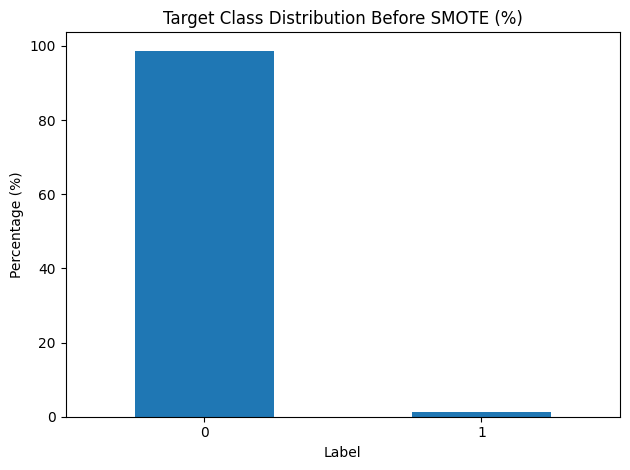

(817651, 60)

In [29]:
# Visualize class imbalance
(y_train.value_counts(normalize=True) * 100).plot(kind="bar")
plt.ylabel("Percentage (%)")
plt.title("Target Class Distribution Before SMOTE (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
X_train.shape

In [30]:
# Apply SMOTE to balance training class distribution
smote = SMOTE(
    sampling_strategy=0.2,  # Target 20% minority samples post-resampling
    random_state=42
)

X_train_scaled, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Training set shape after SMOTE: {X_train_scaled.shape}")

Training set shape after SMOTE: (968497, 60)


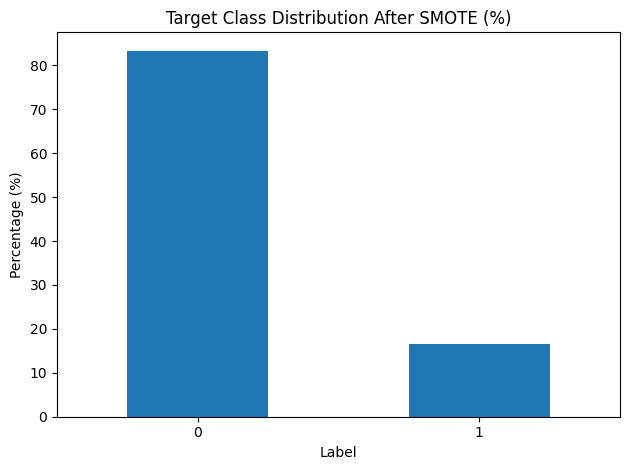

In [31]:
# Visualize improved class balance after SMOTE
(y_train_smote.value_counts(normalize=True) * 100).plot(kind="bar")
plt.ylabel("Percentage (%)")
plt.title("Target Class Distribution After SMOTE (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Saving the Prepared Data

In [32]:
# Drop 'sttl' and 'ct_state_ttl' from training and testing sets.
# These columns were removed due to potential data leakage and redundancy risks.
# Their disproportionately high importance suggested that they might encode dataset-specific or future information,
# leading to overly optimistic model performance. Removing such dominant features helps improve model generalization
# and prevents over-reliance on a small subset of variables.
X_train.drop(columns=["sttl","ct_state_ttl"], inplace=True, axis=1)
X_test.drop(columns=["sttl","ct_state_ttl"], inplace=True, axis=1)

In [33]:
print("train X :", X_train.shape,"; y :", y_train.shape)
print("test X :", X_test.shape,"; y :", y_test.shape)

train X : (817651, 58) ; y : (817651,)
test X : (204413, 58) ; y : (204413,)


In [34]:
# index reset
X_train = X_train.reset_index(drop=True)
y_train = pd.Series(y_train).reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = pd.Series(y_test).reset_index(drop=True)

# Combine X_train and y_train into a single DataFrame and save
train_df = pd.concat([X_train, y_train], axis=1)
train_df.to_csv('train_data.csv', index=False)

# Combine X_test and y_test into a single DataFrame and save
test_df = pd.concat([X_test, y_test], axis=1)
test_df.to_csv('test_data.csv', index=False)

print("Combined training data saved to 'train_data.csv'.")
print("Combined testing data saved to 'test_data.csv'.")

Combined training data saved to 'train_data.csv'.
Combined testing data saved to 'test_data.csv'.


## 8. Feature Engineering

In [127]:
X_train_scaled.drop(columns=["sttl","ct_state_ttl"], inplace=True, axis=1)

In [128]:
features = X_train_scaled.columns

In [129]:
# Feature Selection : PCA
pca = PCA(n_components=0.95)  # Keep 95% of cumulative explained variance

X_train_pca = pca.fit_transform(X_train_scaled)

print(f"PCA - Variance explained: {pca.explained_variance_ratio_.sum():.4f}")

PCA - Variance explained: 0.9553


In [130]:
print("Original shape:", len(features))
print("Reduced shape:", X_train_pca.shape[1])

Original shape: 58
Reduced shape: 20


In [131]:
# Feature Selection : Variance Threshold
selector = VarianceThreshold(threshold=0.01)

X_train_scaled = selector.fit_transform(X_train_scaled)

In [132]:
print("Original shape:", len(features))
print("Reduced shape:", X_train.shape[1])

Original shape: 58
Reduced shape: 58


In [133]:
# Feature Selection : Correlation-Based
X_train_df = pd.DataFrame(X_train_scaled, columns=features[selector.get_support()])

corr_matrix = X_train_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

# Create feature sets excluding correlated duplicates
X_train_corr = X_train_df.drop(columns=to_drop)

print(f"Removed {len(to_drop)} features due to high correlation (|r| > 0.9)")
print(f"Features dropped: {to_drop if to_drop else 'None'}")

Removed 9 features due to high correlation (|r| > 0.9)
Features dropped: ['sloss', 'dloss', 'Dpkts', 'dwin', 'synack', 'ackdat', 'proto_tcp', 'proto_udp', 'state_fin']


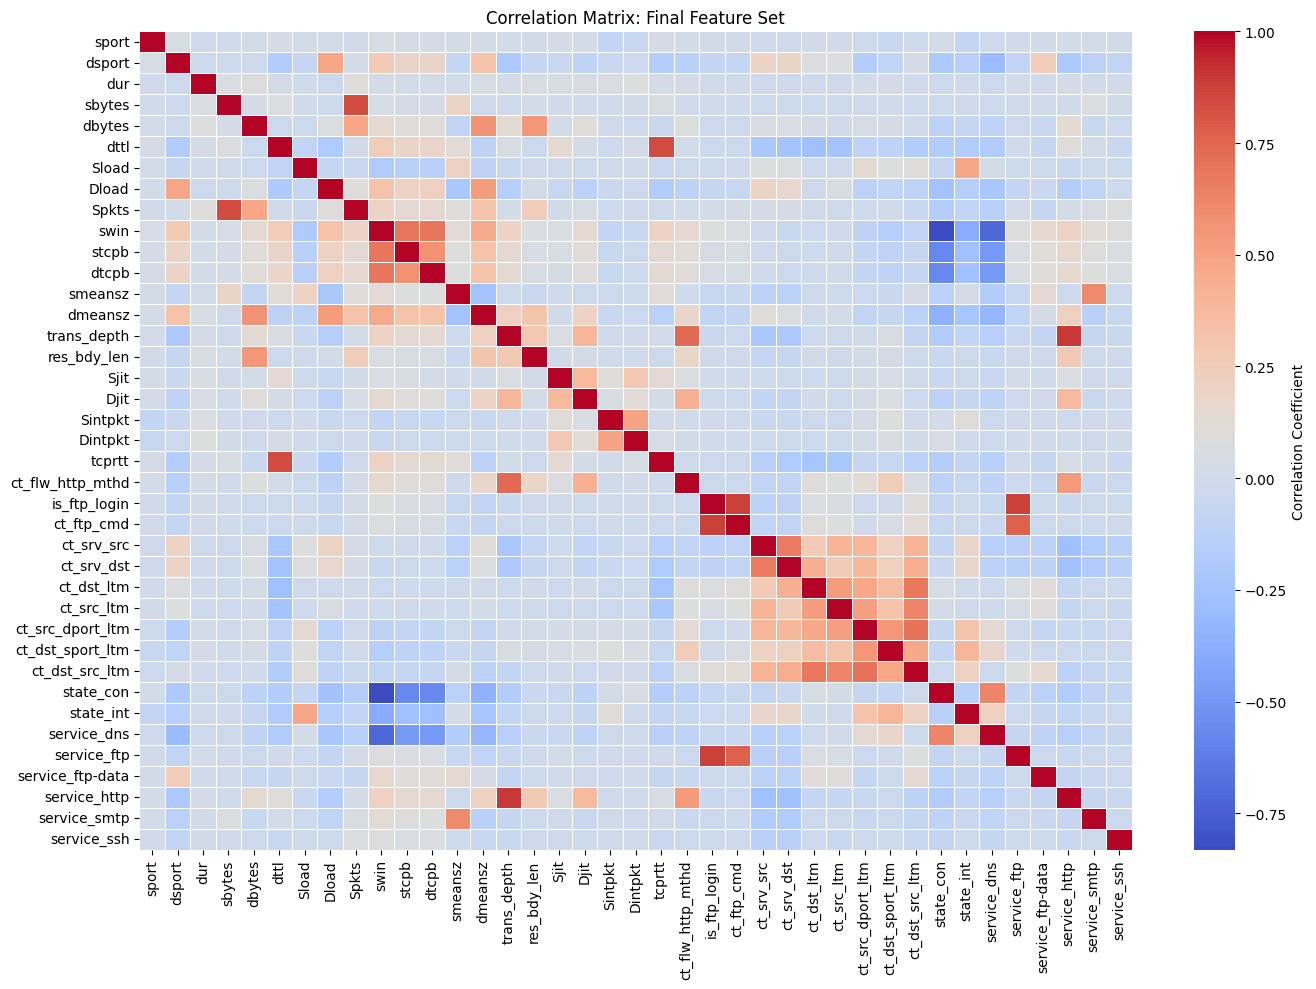

In [134]:
# Visualize correlation structure of remaining features
correlation_matrix = X_train_corr.corr()

# Visual inspection of feature relationships
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", annot=False,
            linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix: Final Feature Set')
plt.tight_layout()
plt.show()

In [135]:
# Feature Selection : Tree-Based & Automatic Selection via XGBoost with imbalance handling
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=len(y_train_smote[y_train_smote==0]) / len(y_train_smote[y_train_smote==1]),  # Weight against majority bias
    random_state=42
)

model.fit(X_train_corr, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [136]:
# Extract and rank feature importances from trained XGBoost model
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X_train_corr.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print("Top 30 Most Important Features:")
print(feat_imp.head(30))

Top 30 Most Important Features:
Dload               0.577295
state_con           0.115078
service_ftp-data    0.101025
dttl                0.072504
state_int           0.063669
dbytes              0.016850
service_dns         0.014761
dsport              0.006029
Sload               0.004166
ct_srv_dst          0.004010
sbytes              0.002879
Sintpkt             0.002809
swin                0.002279
ct_dst_ltm          0.002199
Dintpkt             0.001536
smeansz             0.001440
ct_srv_src          0.001428
ct_src_ltm          0.001100
Sjit                0.001074
ct_dst_sport_ltm    0.001048
ct_dst_src_ltm      0.001026
service_http        0.000802
Spkts               0.000770
ct_src_dport_ltm    0.000766
sport               0.000720
dmeansz             0.000713
tcprtt              0.000543
dur                 0.000391
Djit                0.000380
ct_ftp_cmd          0.000188
dtype: float32


In [137]:
# Select features by importance threshold
selected_features = feat_imp[feat_imp > 0.001].index

print(f"Features selected by importance (> 0.001): {len(selected_features)}")
print(f"Cumulative importance: {feat_imp[feat_imp > 0.001].sum():.4f}")

Features selected by importance (> 0.001): 21
Cumulative importance: 0.9942


In [138]:
# Retains all features with meaningful predictive signal (importance > 0.0001)
X_train_final = X_train_corr[selected_features]

print(f"Final feature set: {X_train_final.shape[1]} features")

Final feature set: 21 features


In [139]:
# This method automatically selects features above the median importance
selector_med = SelectFromModel(model, threshold="median")
selector_mea = SelectFromModel(model, threshold="mean")

X_train_final_med = selector_med.fit_transform(X_train_corr, y_train_smote)
X_train_final_mea = selector_mea.fit_transform(X_train_corr, y_train_smote)

print(f"Automatic selection with median threshold: {X_train_final_med.shape[1]} features")
print(f"Automatic selection with mean threshold: {X_train_final_mea.shape[1]} features")

Automatic selection with median threshold: 20 features
Automatic selection with mean threshold: 5 features


In [140]:
# Comparison of all feature selection approaches
print("-" * 70)
print("FEATURE SELECTION METHODS COMPARISON")
print("-" * 70)
print(f"Original feature count:                    {len(features):3d}")
print(f"After variance threshold (var > 0.01):     {X_train_corr.shape[1]:3d}")
print(f"By importance (threshold > 0.001):         {X_train_final.shape[1]:3d}")
print(f"By automatic selection (median):           {X_train_final_med.shape[1]:3d}")
print(f"By automatic selection (mean):             {X_train_final_mea.shape[1]:3d}")
print(f"After PCA (95% variance):                  {X_train_pca.shape[1]:3d}")
print("-" * 70)

----------------------------------------------------------------------
FEATURE SELECTION METHODS COMPARISON
----------------------------------------------------------------------
Original feature count:                     58
After variance threshold (var > 0.01):      39
By importance (threshold > 0.001):          21
By automatic selection (median):            20
By automatic selection (mean):               5
After PCA (95% variance):                   20
----------------------------------------------------------------------
